# Import necessary packages

In [1]:
import math
import numpy as np 
from numpy.linalg import inv
import matplotlib.pyplot as plt
import openpyxl
import cmath
import graphviz
from array import array

import qiskit as q
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit.visualization import *
from qiskit.quantum_info import Pauli, SparsePauliOp, Operator
from qiskit.transpiler import CouplingMap
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import *
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator, SamplerV2 as Sampler

# Connect to ibm select the device to mimic the error

In [8]:
# Save an IBM Quantum account and set it as your default account.
API_Token = '13d9540e280b61b7a4254fcdb05516180957df07523dfef1924f7d9363699a51826b42e7a063b3fb685f295f6d27f8ff61810a97f503a704c07bc959d6cc6e3f'
QiskitRuntimeService.save_account(
    channel = "ibm_quantum",
    
    instance ='ibm-q-hub-ntu/chen-hong-bin/default',
    token = API_Token,
    set_as_default = True,
    # Use `overwrite=True` if you're updating your token.
    overwrite = True,
)

In [9]:
# Load saved credentials
service = QiskitRuntimeService()

#For real Device
#backend = service.least_busy(operational=True, simulator=False)
backend_nazca = service.backend("ibm_kyiv")
noise_model = NoiseModel.from_backend(backend_nazca)

# Get basis gates from noise model
basis_gates = noise_model.basis_gates

#For FakeSimulator
#backend = FakeManilaV2()

# Get coupling map from backend
coupling_map = [[0, 1], [1, 2], [3, 2], [3, 4]]

#For Aer
backend = AerSimulator(noise_model=noise_model,
                       coupling_map=coupling_map,
                       basis_gates=basis_gates)
#backend = AerSimulator()
#backend = AerSimulator.from_backend(backend_nazca)

backendqubitNum = backend.num_qubits

# Do 2-qubits measurement PEC

In [10]:
#Build Four Initial State |0>, |1>, |0>+|1>, |0>-i|1>
qreg = QuantumRegister(2, 'q')
creg = ClassicalRegister(2, 'c')
q0_init = {}
q1_init = {}

for i in range (2):
    #rho0 state |0>
    InitCirZero = QuantumCircuit(qreg, creg)
    #rho1 state |1>
    InitCirOne = QuantumCircuit(qreg, creg)
    InitCirOne.x(i)
    #rho2 state |0>+|1>
    InitCirPlus = QuantumCircuit(qreg, creg)
    InitCirPlus.h(i)
    #rho3 state |0>+i|1>
    InitCirRight = QuantumCircuit(qreg, creg)
    InitCirRight.h(i)
    InitCirRight.s(i)
    
    if i == 0:
        q0_init = {'q0zero':InitCirZero, 'q0one':InitCirOne, 'q0plus':InitCirPlus, 'q0right':InitCirRight}
    else:
        q1_init = {'q1zero':InitCirZero, 'q1one':InitCirOne, 'q1plus':InitCirPlus, 'q1right':InitCirRight}

# Store the initial circuits in a dictionary
InitialState = {}
for q0, q0state in q0_init.items():
    for q1, q1state in q1_init.items():
        initcomb = q.circuit.QuantumCircuit.compose(q0state, q1state)
        InitialState.update({f'{q0}_{q1}':initcomb})

In [11]:
# Store the measurement circuits in a dictionary
Measurement = {}
pau = ['I', 'X', 'Y', 'Z']
for i in pau:
    for j in pau:
        meascomb = Pauli('I' * 28 + j + i)
        Measurement.update({f'meas{j}{i}':meascomb})
print(Measurement)

{'measII': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIII'), 'measXI': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIXI'), 'measYI': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIYI'), 'measZI': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIZI'), 'measIX': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIIX'), 'measXX': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIXX'), 'measYX': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIYX'), 'measZX': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIZX'), 'measIY': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIIY'), 'measXY': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIXY'), 'measYY': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIYY'), 'measZY': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIZY'), 'measIZ': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIIZ'), 'measXZ': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIXZ'), 'measYZ': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIYZ'), 'measZZ': Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIZZ')}


In [12]:
job = {}
estimator = Estimator(mode=backend)
for MeasName, Measure in Measurement.items():
    for InitName, Initial in InitialState.items():
        CirTran = q.compiler.transpile(Initial, backend=backend, optimization_level=0)
        job.update({f'{InitName}_{MeasName}':estimator.run([(CirTran, Measure)])})

In [13]:
result_origin = []
for index, job_name in job.items():
    res = job_name.result()
    result_origin.append(res[0].data.evs)
result_origin

[array(1.),
 array(1.),
 array(1.),
 array(1.),
 array(1.),
 array(1.),
 array(1.),
 array(1.),
 array(1.),
 array(1.),
 array(1.),
 array(1.),
 array(1.),
 array(1.),
 array(1.),
 array(1.),
 array(-0.00097656),
 array(-0.02246094),
 array(0.99121094),
 array(0.00439453),
 array(0.00048828),
 array(0.),
 array(0.99365234),
 array(0.01416016),
 array(-0.01855469),
 array(-0.00927734),
 array(0.98925781),
 array(-0.02294922),
 array(0.01025391),
 array(-0.00537109),
 array(0.9921875),
 array(-0.00488281),
 array(-0.02734375),
 array(-0.00830078),
 array(0.01220703),
 array(0.99072266),
 array(-0.02880859),
 array(-0.02099609),
 array(0.01904297),
 array(0.99072266),
 array(-0.00146484),
 array(0.00976562),
 array(-0.00439453),
 array(0.98681641),
 array(-0.00097656),
 array(0.01318359),
 array(0.01074219),
 array(0.99121094),
 array(0.99169922),
 array(-0.99121094),
 array(0.00146484),
 array(-0.01464844),
 array(0.9921875),
 array(-0.9921875),
 array(-0.00878906),
 array(0.01611328),
 

In [14]:
g = np.array(result_origin).reshape(16, 16)
g

array([[ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00],
       [-9.76562500e-04, -2.24609375e-02,  9.91210938e-01,
         4.39453125e-03,  4.88281250e-04,  0.00000000e+00,
         9.93652344e-01,  1.41601562e-02, -1.85546875e-02,
        -9.27734375e-03,  9.89257812e-01, -2.29492188e-02,
         1.02539062e-02, -5.37109375e-03,  9.92187500e-01,
        -4.88281250e-03],
       [-2.73437500e-02, -8.30078125e-03,  1.22070312e-02,
         9.90722656e-01, -2.88085938e-02, -2.09960938e-02,
         1.90429688e-02,  9.90722656e-01, -1.46484375e-03,
         9.76562500e-03, -4.39453125e-03,  9.86816406e-01,
        -9.76562500e-04,  1.31835938e-02,  1.07421875e-02,
         9.91210938e-01],
       [ 9.91699219e-01, -9.91210938e

In [15]:
#Create State Preparation Matrix A
A_single = np.array([[1, 1, 1, 1],
                     [0, 0, 1, 0],
                     [0, 0, 0, 1],
                     [1,-1, 0, 0]])
A = np.kron(A_single, A_single)
#print(A)

#Calculate Readout Matrix by the quation B = g * A^-1
A_inv = inv(A)
#print(A_inv)
B = np.matmul(g, A_inv)
B_inv = inv(B)
print(B_inv)
'''
#Calculate observable X, Y, Z
a_x = np.array([[0, 1, 0, 0]])
a_y = np.array([[0, 0, 1, 0]])
a_z = np.array([[0, 0, 0, 1]])

B_inv = inv(B)
q_x = np.matmul(a_x, B_inv)
q_y = np.matmul(a_y, B_inv)
q_z = np.matmul(a_z, B_inv)
print(B_inv, '\n\n', q_x, '\n\n', q_y, '\n\n', q_z)
'''

[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 5.29582091e-03  1.00210956e+00 -1.43035621e-02 -5.70488980e-03
   9.19009813e-03 -5.00644508e-03  2.36855755e-02  1.03904091e-02
  -7.32229090e-03  8.09999823e-03  2.10590369e-02 -1.57739487e-03
   6.10106761e-03 -4.68223124e-03 -1.54727726e-03 -5.29634606e-03]
 [ 2.02072071e-02 -3.61377854e-02  9.90797410e-01  7.05368102e-03
  -2.45897019e-02  4.59120452e-02  2.37718315e-02 -2.22151424e-03
  -2.57313404e-02  3.11840613e-02  2.30755931e-02 -1.05762122e-03
  -3.49703886e-03  5.97818293e-03  3.39793709e-03  3.91815776e-03]
 [ 4.15525308e-04  3.47923146e-03 -1.09713262e-03  1.00823011e+00
  -1.60325311e-03 -2.01417603e-02 -2.32357434e-02  7.39955847e-04
   1.99071313e-03 -1.61313013e-02  1.70355841e-02  4.20614771e-03
  -8.28

"\n#Calculate observable X, Y, Z\na_x = np.array([[0, 1, 0, 0]])\na_y = np.array([[0, 0, 1, 0]])\na_z = np.array([[0, 0, 0, 1]])\n\nB_inv = inv(B)\nq_x = np.matmul(a_x, B_inv)\nq_y = np.matmul(a_y, B_inv)\nq_z = np.matmul(a_z, B_inv)\nprint(B_inv, '\n\n', q_x, '\n\n', q_y, '\n\n', q_z)\n"

In [16]:
import numpy as np
import csv

# 將矩陣存成CSV檔案
filename = 'matrix_B_inv.csv'
np.savetxt(filename, B_inv, delimiter=",", fmt="%.10e")

print(f"矩陣已成功存成CSV檔案：{filename}")

矩陣已成功存成CSV檔案：matrix_B_inv.csv


# Do 2-qubits Cnot PEC

In [17]:
#Build each set of circuits with Initialstates, cnot gate, measurements
#Cnot gate
Cnotgate = QuantumCircuit(qreg, creg)
Cnotgate.cx(0, 1)
Circuit = {}
for InitName, Initial in InitialState.items():
    circuit = q.circuit.QuantumCircuit.compose(Initial, Cnotgate)
    Circuit.update({f'{InitName}':circuit})
Circuit

{'q0zero_q1zero': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1b798240ca0>,
 'q0zero_q1one': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1b798240dc0>,
 'q0zero_q1plus': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1bc60dc5f70>,
 'q0zero_q1right': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1bc60dc5d30>,
 'q0one_q1zero': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1bc60dc5760>,
 'q0one_q1one': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1bc60ddb040>,
 'q0one_q1plus': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1bc60ddb190>,
 'q0one_q1right': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1bc60ddb2e0>,
 'q0plus_q1zero': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1bc60ddb430>,
 'q0plus_q1one': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1bc60ddb610>,
 'q0plus_q1plus': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1bc60ddb760>,
 'q0plus_q1right': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1bc60ddb550>,
 'q0righ

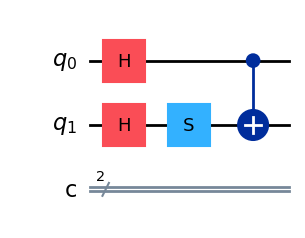

In [18]:
Circuit['q0plus_q1right'].draw(output='mpl') 

In [19]:
job_cnot = {}
for MeasName, Measure in Measurement.items():
    for CirName, Cir in Circuit.items():
        CirTran = q.compiler.transpile(Cir, backend=backend, optimization_level=0)
        job_cnot.update({f'{CirName}_{MeasName}':estimator.run([(CirTran, Measure)])})

In [20]:
result_cnot_origin = []
for index, job_name in job_cnot.items():
    res = job_name.result()
    result_cnot_origin.append(res[0].data.evs)
g_cnot = np.array(result_cnot_origin).reshape(16, 16)
g_cnot

array([[ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00],
       [-1.26953125e-02, -2.68554688e-02,  9.75097656e-01,
        -2.58789062e-02, -1.95312500e-02,  9.76562500e-03,
         9.72656250e-01, -1.61132812e-02, -1.17187500e-02,
        -2.78320312e-02,  9.79980469e-01,  2.49023438e-02,
         9.76562500e-04, -2.44140625e-03,  9.71679688e-01,
        -1.90429688e-02],
       [ 6.34765625e-03,  4.88281250e-03,  2.05078125e-02,
         9.74609375e-01,  0.00000000e+00, -5.85937500e-03,
         4.19921875e-02, -9.73632812e-01, -1.70898438e-02,
        -2.19726562e-02, -1.80664062e-02, -1.70898438e-02,
         6.34765625e-03, -4.39453125e-03,  9.76562500e-03,
        -2.24609375e-02],
       [ 9.79003906e-01, -9.77050781e

In [21]:
#Calculate Readout Matrix by the quation Uerror = B^-1 * g_cnot * A^-1
ErrorCnot = np.matmul(np.matmul(B_inv, g_cnot), A_inv)
print(ErrorCnot)
ErrorCnot_inv = inv(ErrorCnot)
# print(ErrorCnot_inv)

[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-7.11955176e-03  9.87728083e-01 -1.00293816e-02 -9.14679627e-03
  -1.25654083e-02  2.41524831e-02  5.26178468e-02 -7.65615350e-03
   1.95634898e-02 -2.05877422e-02 -2.02336120e-02  2.84014582e-02
  -1.72169112e-03  4.91112625e-03 -1.09001735e-02  4.82174445e-03]
 [ 2.26240723e-02 -5.95304347e-03  3.65741997e-03  5.60929651e-03
   2.36783827e-02 -5.21599403e-02 -1.21822475e-03 -2.18814702e-02
   2.82545924e-02 -4.39935163e-02 -2.15561728e-02  2.54326150e-02
   9.71421686e-04 -7.52179391e-03  9.60659373e-01  6.08256441e-03]
 [ 2.32113410e-03 -5.05303687e-03  2.71584562e-02 -2.22410587e-04
  -6.78721372e-03  3.08195850e-02 -1.73494419e-02 -1.33783523e-02
  -1.25895217e-02  4.57041605e-02 -1.43525556e-02 -2.77017566e-02
  -1.83

In [22]:
import numpy as np
import csv
# 將矩陣存成CSV檔案
filename = 'matrix_ErrorCnot.csv'
np.savetxt(filename, ErrorCnot, delimiter=",", fmt="%.10e")
print(f"矩陣已成功存成CSV檔案：{filename}")

矩陣已成功存成CSV檔案：matrix_ErrorCnot.csv


# Build PTM of the Ideal Ucnot 

In [4]:
#Construct Ideal Ucnot
pauli = ["I", "X", "Y", "Z"]
pauli_pair = {}
for i in pauli:
    for j in pauli:
        pauli_pair.update({f"{i}{j}":np.array(Pauli(f"{i}{j}").to_matrix())})

def evolution(gate, state):
    return np.matmul(np.matmul(gate, state), np.conj(gate).T)
        
Cnot = np.array([[1, 0, 0, 0],
                 [0, 1, 0, 0],
                 [0 ,0, 0, 1],
                 [0, 0, 1, 0]])
IdealCnot = np.ones((16,16),  dtype=complex)
i = 0
for index1, matrix1 in pauli_pair.items():
    j = 0
    for index2, matrix2 in pauli_pair.items():
        applycnot = evolution(Cnot, matrix1)
        element = np.matmul(matrix2, applycnot)
        IdealCnot[i][j] = np.round(np.trace(element)/4)
        j+=1
    i+=1 

print(IdealCnot)

{'II': array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]]), 'IX': array([[0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j]]), 'IY': array([[0.+0.j, 0.-1.j, 0.+0.j, 0.+0.j],
       [0.+1.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.-1.j],
       [0.+0.j, 0.+0.j, 0.+1.j, 0.+0.j]]), 'IZ': array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]]), 'XI': array([[0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j]]), 'XX': array([[0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+

In [25]:
import numpy as np
import csv
# 將矩陣存成CSV檔案
filename = 'matrix_IdealCnot.csv'
np.savetxt(filename, IdealCnot, delimiter=",", fmt="%.10e")
print(f"矩陣已成功存成CSV檔案：{filename}")

矩陣已成功存成CSV檔案：matrix_IdealCnot.csv


In [27]:
#Construct Error channel
LambdaError = np.matmul(inv(IdealCnot), ErrorCnot)
# print(np.round(LambdaError2))
print(LambdaError.real)

[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-7.11955176e-03  9.87728083e-01 -1.00293816e-02 -9.14679627e-03
  -1.25654083e-02  2.41524831e-02  5.26178468e-02 -7.65615350e-03
   1.95634898e-02 -2.05877422e-02 -2.02336120e-02  2.84014582e-02
  -1.72169112e-03  4.91112625e-03 -1.09001735e-02  4.82174445e-03]
 [ 2.47020099e-02 -7.60700910e-03  9.67817018e-01 -8.19771812e-03
   3.66713579e-03 -3.00573643e-02  2.20612675e-02 -2.13712527e-02
  -2.37951206e-02 -3.53008486e-02  3.78761753e-02  2.27740590e-02
   3.77595338e-03 -1.35791023e-02 -1.56926944e-02 -9.63046840e-03]
 [-4.18743496e-03  2.69212835e-02 -4.21471376e-03  9.85098271e-01
  -2.51007899e-02 -4.60321638e-02 -3.01587121e-02  1.00104259e-02
  -6.08765169e-03  1.99352477e-02 -2.49783876e-03  2.98846656e-02
  -2.28

# Pauli Twirling

In [68]:
pauli_transfer = {}
for channel, matrix in pauli_pair.items():
    new_matrix = evolution(Cnot, matrix)
    for new_channel, comp_matrix in pauli_pair.items():
        if np.array_equal(new_matrix, comp_matrix) or np.array_equal(new_matrix, -comp_matrix):
            pauli_transfer.update({channel:new_channel})
print(pauli_pair_afterCnot)

{'II': 'II', 'IX': 'IX', 'IY': 'ZY', 'IZ': 'ZZ', 'XI': 'XX', 'XX': 'XI', 'XY': 'YZ', 'XZ': 'YY', 'YI': 'YX', 'YX': 'YI', 'YY': 'XZ', 'YZ': 'XY', 'ZI': 'ZI', 'ZX': 'ZX', 'ZY': 'IY', 'ZZ': 'IZ'}


In [69]:
# Function to generate measurement circuits
def generate_pauli_circuits(index):
    circuits = {
        "I": QuantumCircuit(1, 1),
        "X": QuantumCircuit(1, 1),
        "Y": QuantumCircuit(1, 1),
        "Z": QuantumCircuit(1, 1),
    }
    # X-measurement
    circuits["X"].x(index)
    # Y-measurement
    circuits["Y"].y(index)
    # Z-measurement
    circuits["Z"].z(index)

    return circuits

# Generate circuits for q0 and q1
pauli_circuit = {}
pauli_circuit.update(generate_pauli_circuits(0))

# Store the measurement circuits in a dictionary
PauliTwirling = {}
for q0_label, q0 in pauli_circuit.items():
    for q1_label, q1 in pauli_circuit.items():
        pauli_comb = q.circuit.QuantumCircuit.compose(q0, q1)
        PauliTwirling.update({f"{q0_label}{q1_label}": pauli_comb})
print(PauliTwirling)

{'II': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001C0E60E94C0>, 'IX': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001C0E60E9AF0>, 'IY': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001C0E60E92B0>, 'IZ': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001C0E9CAA0D0>, 'XI': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001C0E9CAA220>, 'XX': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001C0E9CAA070>, 'XY': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001C0E9CAA490>, 'XZ': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001C0E9CAA5E0>, 'YI': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001C0E9CAA760>, 'YX': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001C0E9CAA8B0>, 'YY': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001C0E9CAAA00>, 'YZ': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001C0E9CAAB50>, 'ZI

In [78]:
Twirling_circuit_set = {}
for firstPauli, secondPauli in pauli_pair_afterCnot.items():
    Twirling_circuit = {}
    for InitName, Initial in InitialState.items():
        AddPauli = q.circuit.QuantumCircuit.compose(Initial, PauliTwirling[firstPauli])
        AddCnot = q.circuit.QuantumCircuit.compose(AddPauli, Cnotgate)
        AddPauliInverse = q.circuit.QuantumCircuit.compose(AddCnot, PauliTwirling[secondPauli])
        Twirling_circuit.update({InitName:AddPauliInverse})
    Twirling_circuit_set.update({firstPauli:Twirling_circuit})

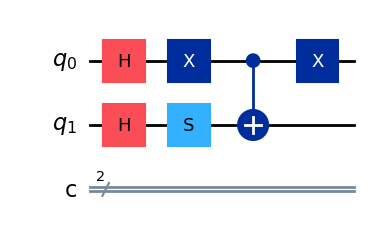

In [80]:
Twirling_circuit_set['IX']['q0plus_q1right'].draw(output='mpl') 

In [ ]:
Twirling_job = {}
for pauli, circuit_set in Twirling_circuit_set.items():
    job = {}
    for MeasName, Measure in Measurement.items():
        for CirName, Cir in circuit_set.items():
            CirTran = q.compiler.transpile(Cir, backend=backend, optimization_level=0)
            job.update({f'{CirName}_{MeasName}':estimator.run([(CirTran, Measure)])})
    Twirling_job.update({pauli:job})

In [ ]:
Sum_twirling = np.zero(16,16)
for pauli, job_set in Twirling_job.items():
    result_each_twirling = []
    for index, job_name in job_set.items():
        res = job_name.result()
        result_each_twirling.append(res[0].data.evs)
    g_twirling = (np.array(result_each_twirling).reshape(16, 16))
    ErrorCnot_twirling = np.matmul(np.matmul(B_inv, g_twirling), A_inv)
    Sum_twirling = Sum_twirling + ErrorCnot_twirling

Avg_twirling = Sun_twirling/16
Avg_gateError = np.matmul(inv(IdealCnot), Avg_twirling)